In [8]:
# Lets read the dataset
words = open('../names.txt', 'r').read().splitlines()

In [10]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [13]:
length = len(words)
maxi = max(len(word) for word in words)
mini = min(len(word) for word in words)
print(maxi, mini, length)

15 2 32033


In [ ]:
## Biagram : It is besically a technique used to predict the next character (so if first character is given then it will help to predict immediate next character)

In [ ]:
# Implementing biagram manually
occurences = {}
for word in words:
    value = ['<S>'] + list(word) + ['<E>']
    for ch1, ch2 in zip(value, value[1:]):
        data = (ch1,ch2)
        occurences[data] = occurences.get(data, 0) + 1

In [17]:
occurences

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [28]:
characters = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(characters)}
stoi['<S>'] = 0
stoi['<E>'] = 27
stoi
itos = {i:s for s,i in stoi.items()}

In [37]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [34]:
## Create a 2d matrix to represent the occurances
mat = torch.zeros(28,28, dtype=torch.int32)

In [ ]:
for data, occ in occurences.items():
    val = list(data)
    row = stoi.get(val[0])
    col = stoi.get(val[1])
    mat[row,col] = occ


('<S>', 'e') 1531
('e', 'm') 769
('m', 'm') 168
('m', 'a') 2590
('a', '<E>') 6640
('<S>', 'o') 394
('o', 'l') 619
('l', 'i') 2480
('i', 'v') 269
('v', 'i') 911
('i', 'a') 2445
('<S>', 'a') 4410
('a', 'v') 834
('v', 'a') 642
('<S>', 'i') 591
('i', 's') 1316
('s', 'a') 1201
('a', 'b') 541
('b', 'e') 655
('e', 'l') 3248
('l', 'l') 1345
('l', 'a') 2623
('<S>', 's') 2055
('s', 'o') 531
('o', 'p') 95
('p', 'h') 204
('h', 'i') 729
('<S>', 'c') 1542
('c', 'h') 664
('h', 'a') 2244
('a', 'r') 3264
('r', 'l') 413
('l', 'o') 692
('o', 't') 118
('t', 't') 374
('t', 'e') 716
('e', '<E>') 3983
('<S>', 'm') 2538
('m', 'i') 1256
('a', 'm') 1634
('m', 'e') 818
('<S>', 'h') 874
('r', 'p') 14
('p', 'e') 197
('e', 'r') 1958
('r', '<E>') 1377
('e', 'v') 463
('v', 'e') 568
('l', 'y') 1588
('y', 'n') 1826
('n', '<E>') 6763
('b', 'i') 217
('i', 'g') 428
('g', 'a') 330
('a', 'i') 1650
('i', 'l') 1345
('l', '<E>') 1314
('y', '<E>') 2007
('i', 'z') 277
('z', 'a') 860
('e', 't') 580
('t', 'h') 647
('h', '<E>') 240

In [36]:
mat

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929,    0],
        [   0,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435, 6640],
        [   0,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0,  114],
        [   0,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4,   97],
        [   0, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1,  516],
        [   0,  679,

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

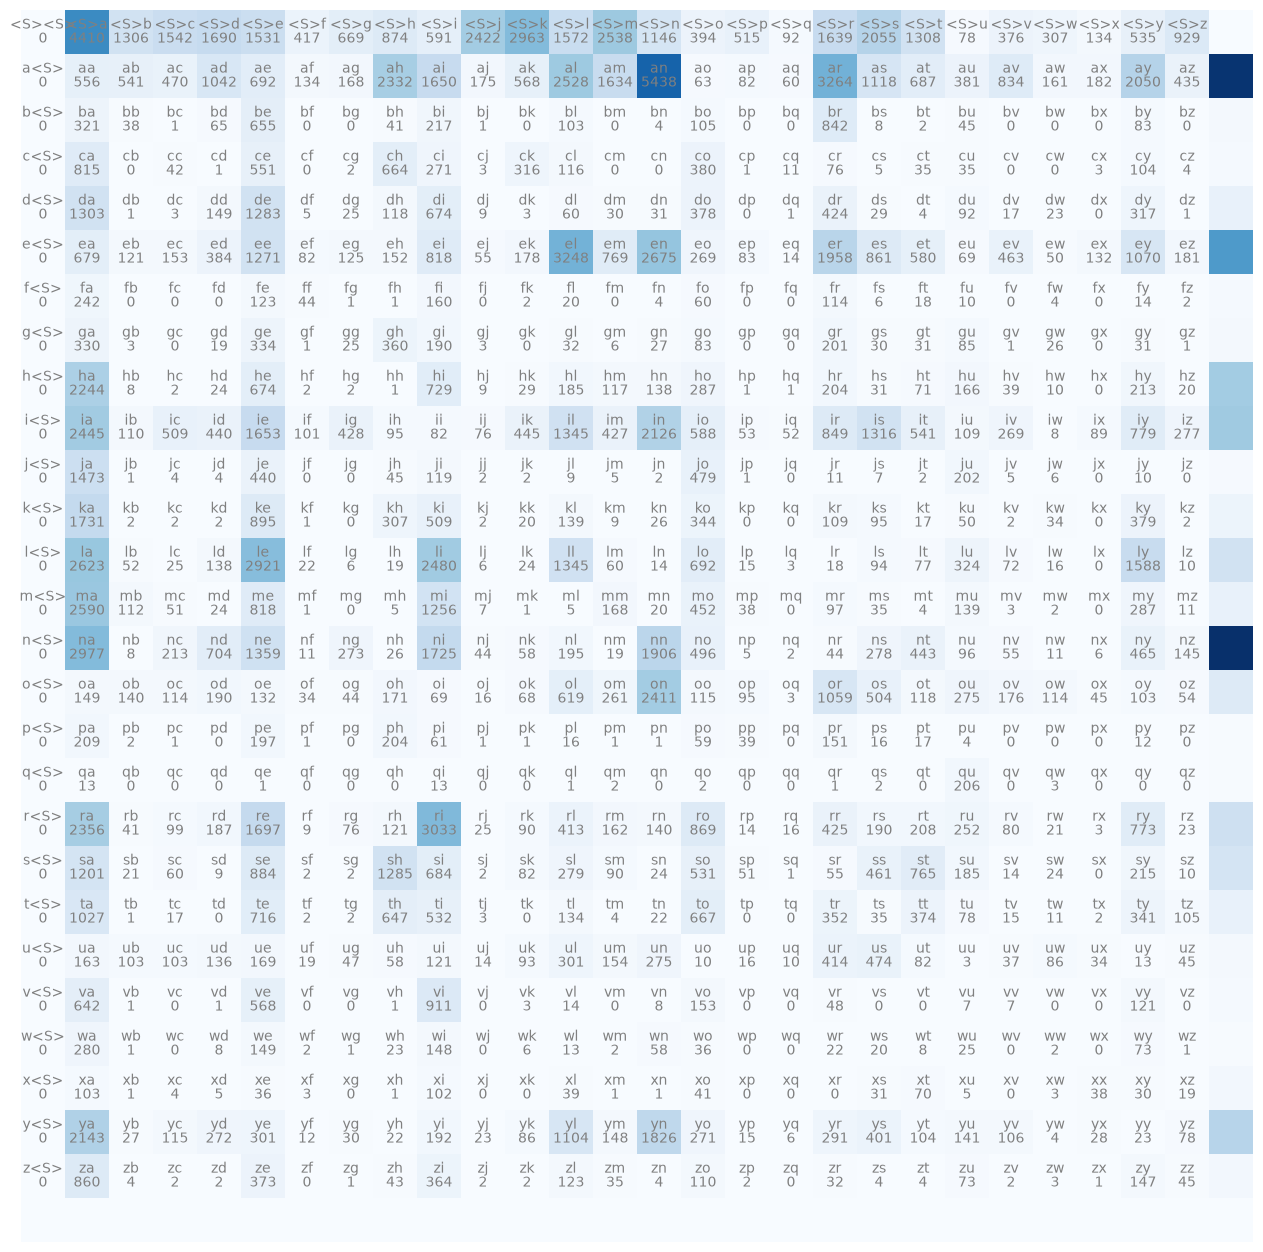

In [38]:
## Display the 2d matrix

plt.figure(figsize=(16,16))
plt.imshow(mat, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, mat[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [ ]:
##Above representation is fine but you look at the matrix you will notice that possibility of <S> coming at the end is 0 and same possibility/occurance of <E> coming first is 0
## because <S> can only be used at the start and <E> at the end so let normalise this 2d matrix and just use '.'